# What is `torch.nn` really?

Based on https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html

This tutorial peels back the mask from high-level abstractions in `torch.nn`, `torch.optim`, etc. by training a neural net without them, then introducing them gradually to demonstrate how they fit.

## MNIST data setup

MNIST: https://yann.lecun.com/exdb/mnist/index.html

In [2]:
from pathlib import Path
import requests

In [4]:
DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
    content = requests.get(URL + FILENAME).content
    (PATH / FILENAME).open("wb").write(content)

In [6]:
# This dataset is in numpy array format, and has been stored using pickle

import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

/var/folders/8q/cd8z0zm51sz39fqj8fzj4rd80000gn/T/ipykernel_76563/607019417.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


Each image is 28 x 28, and is being stored as a flattened row of length 784 (=28x28). Let’s take a look at one; we need to reshape it to 2d first.

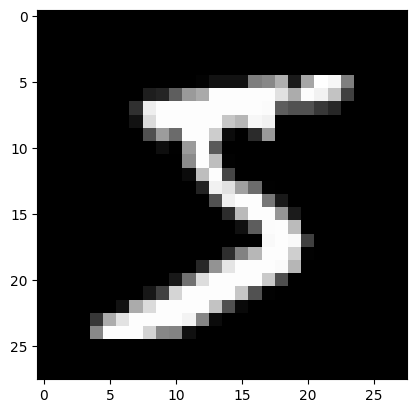

(50000, 784)


In [9]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

In [10]:
# PyTorch uses torch.tensor, rather than numpy arrays, so we need to convert our data.

import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)

n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


## Neural net from scratch (without `torch.nn`)

Let’s first create a model using nothing but PyTorch tensor operations.

PyTorch provides methods to create random or zero-filled tensors, which we will use to create our weights and bias for a simple linear model. These are just regular tensors, with one very special addition: we tell PyTorch that they require a gradient. This causes PyTorch to record all of the operations done on the tensor, so that it can calculate the gradient during back-propagation automatically!

For the weights, we set `requires_grad` **after** the initialization, since we don’t want that step included in the gradient. (Note that a trailing _ in PyTorch signifies that the operation is performed in-place.)

*Note*: We are initializing the weights here with [Xavier initialisation](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf) (by multiplying with `1/sqrt(n)`).

In [ ]:
import math

weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

Thanks to PyTorch’s ability to calculate gradients automatically, we can use any standard Python function (or callable object) as a model!

So let’s just write a plain matrix multiplication and broadcasted addition to create a simple linear model. We also need an activation function, so we’ll write log_softmax and use it.

Although PyTorch provides lots of prewritten loss functions, activation functions, and so forth, you can easily write your own using plain python. PyTorch will even create fast accelerator or vectorized CPU code for your function automatically.

In [ ]:
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
    return log_softmax(xb @ weights + bias)

In the above, the `@` stands for the matrix multiplication operation.

We will call our function on one batch of data (in this case, 64 images). This is one forward pass. Note that our predictions won’t be any better than random at this stage, since we start with random weights.

In [ ]:
bs = 64 # batch size

xb = x_train[0:bs] # a mini-batch from x
preds = model(xb) # predictions
print(preds[0], preds.shape)


tensor([-2.0175, -2.0318, -2.2565, -2.7364, -1.9761, -1.8769, -2.4354, -2.9599,
        -2.5954, -2.8014], grad_fn=<SelectBackward0>) torch.Size([64, 10])


As you see, the preds tensor contains not only the tensor values, but also a gradient function. We’ll use this later to do backprop.

Let’s implement negative log-likelihood to use as the loss function (again, we can just use standard Python):

In [ ]:
def nll(input, target):
    # input has shape (batch_size, num_classes)
    # target has shape (batch_size,)
    # values of target are 0 to num_classes - 1
    # So the following is equivalent to
    # -input[[0, 1, 2, ...], [y0, y1, y2, ...]].mean()
    # For each input item, take the item whose index matches the target class
    # If an input row contains the predicted probability for each class
    # in the columns, the selecting the column corresponding to the
    # target class returns the likelihood of getting the right
    # answer. We want to maximize this likelihood.
    # Or minimize the negative likelihood.
    # Instead of actual probabilities, we use log for
    # better numerical stability on computers
    # (better to add logs than multiply really small numbers which risks precision loss).
    # That returns shape (batch_size)
    # Then we take the mean across the batch.
    return -input[range(target.shape[0]), target].mean()

loss_func = nll

Let’s check our loss with our random model, so we can see if we improve after a backprop pass later.

In [ ]:
yb = y_train[0:bs]
print(loss_func(preds, yb))

tensor(2.3802, grad_fn=<NegBackward0>)


Let’s also implement a function to calculate the accuracy of our model.

For each prediction, if the index with the largest value matches the target value, then the prediction was correct.

In [ ]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [ ]:
print(accuracy(preds, yb))

tensor(0.0781)


We can now run a training loop. For each iteration, we will:

- select a mini-batch of data (of size bs)
- use the model to make predictions
- calculate the loss
- `loss.backward()` updates the gradients of the model, in this case, weights and bias.

We now use these gradients to update the weights and bias. We do this within the `torch.no_grad()` context manager, because we do not want these actions to be recorded for our next calculation of the gradient. You can read more about how PyTorch’s Autograd records operations [here](https://pytorch.org/docs/stable/notes/autograd.html).

We then set the gradients to zero, so that we are ready for the next loop. Otherwise, our gradients would record a running tally of all the operations that had happened (i.e. `loss.backward()` adds the gradients to whatever is already stored, rather than replacing them).

**Tip**: You can use the standard python debugger to step through PyTorch code, allowing you to check the various variable values at each step. Uncomment `set_trace()` below to try it out.

In [85]:
from IPython.core.debugger import set_trace

lr = 0.5 # learning_rate
epochs = 2 # how many epochs to train for

for epoch in range(epochs):
    print("Epoch", epoch)
    for i in range((n - 1) // bs + 1):
        # set_trace()
        start_i = i * bs
        end_i = start_i + bs
        xb = x_train[start_i: end_i]
        yb = y_train[start_i: end_i]

        pred = model(xb)
        loss = loss_func(pred, yb)

        # computes gradient for each
        # weight in the model
        loss.backward()

        # no grad so these computations
        # are not recorded for the next gradient
        # calculation
        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            # reset grads so we don't "pollute"
            # next batch.
            weights.grad.zero_()
            bias.grad.zero_()



Epoch 0
Epoch 1


That’s it: we’ve created and trained a minimal neural network (in this case, a logistic regression, since we have no hidden layers) entirely from scratch!

Let’s check the loss and accuracy and compare those to what we got earlier. We expect that the loss will have decreased and accuracy to have increased, and they have.

In [86]:

print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0537, grad_fn=<NegBackward0>) tensor(1.)


tensor(9)
tensor(9)
